# Exercise 04: Merge and Heatmap — Demographic Bias Audit
# Cluster 4 - Pandas and Visualization
# Framework: EU AI Act Article 10 (Data Governance), NIST AI RMF Map + Measure
# Case Study: Recruitment AI 🟢

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

In [7]:
# Dataset 1: Hiring decisions
applicants = pd.DataFrame({
    'applicant_id': range(1, 51),
    'test_score': np.random.randint(50, 100, 50),
    'hired': np.random.choice([0, 1], 50, p=[0.6, 0.4])
})

In [10]:
applicants.head(10)

,applicant_id,test_score,hired
0,1,88,0
1,2,78,1
2,3,64,0
3,4,92,0
4,5,57,0
5,6,70,0
6,7,88,1
7,8,68,0
8,9,72,1
9,10,60,0


In [9]:
# Dataset 2: Demographic information
demographics = pd.DataFrame({
    'applicant_id': range(1, 51),
    'gender': np.random.choice(['Woman', 'Man'], 50, p=[0.5, 0.5]),
    'age_group': np.random.choice(['20-30', '31-40', '41-50'], 50)
})
demographics.head(10)

,applicant_id,gender,age_group
0,1,Man,41-50
1,2,Woman,41-50
2,3,Man,31-40
3,4,Woman,41-50
4,5,Man,31-40
5,6,Woman,31-40
6,7,Man,31-40
7,8,Woman,31-40
8,9,Woman,31-40
9,10,Woman,20-30


In [11]:
# Merge 1: Combine hiring decisions with demographic data
audit_df = pd.merge(applicants, demographics, on='applicant_id', how='inner')
print(audit_df.shape)
audit_df.head()

(50, 5)


,applicant_id,test_score,hired,gender,age_group
0,1,88,0,Man,41-50
1,2,78,1,Woman,41-50
2,3,64,0,Man,31-40
3,4,92,0,Woman,41-50
4,5,57,0,Man,31-40


In [12]:
# Dataset 3: Interview panel scores (only 40 of 50 applicants were interviewed)
panel_scores = pd.DataFrame({
    'applicant_id': np.random.choice(range(1, 51), 40, replace=False),
    'panel_score': np.random.randint(40, 100, 40)
})

In [15]:
panel_scores.head(10) 


,applicant_id,panel_score
0,5,54
1,11,93
2,41,82
3,35,99
4,43,76
5,10,72
6,44,47
7,19,92
8,45,99
9,36,83


In [16]:
panel_scores.shape

(40, 2)

In [17]:
# Merge 2: Add panel scores to audit dataframe
# Left join — keep all 50 applicants, even those without panel scores
audit_full = pd.merge(audit_df, panel_scores, on='applicant_id', how='left')
print(audit_full.shape)
audit_full.isnull().sum()

(50, 6)


applicant_id     0
test_score       0
hired            0
gender           0
age_group        0
panel_score     10
dtype: int64

In [18]:
audit_full.head()

,applicant_id,test_score,hired,gender,age_group,panel_score
0,1,88,0,Man,41-50,79.0
1,2,78,1,Woman,41-50,NaN
2,3,64,0,Man,31-40,NaN
3,4,92,0,Woman,41-50,52.0
4,5,57,0,Man,31-40,54.0


In [19]:
# Who didn't make it to interview?
missing_panel = audit_full[audit_full['panel_score'].isnull()]
missing_panel['gender'].value_counts()

gender
Man      6
Woman    4
Name: count, dtype: int64

In [20]:
# Create a contingency table: hiring rates by gender and age group
pivot_table = audit_full.groupby(['gender', 'age_group'])['hired'].agg(['sum', 'count'])
pivot_table['hiring_rate'] = (pivot_table['sum'] / pivot_table['count'] * 100).round(1)
pivot_table_display = pivot_table[['hiring_rate']].unstack()
print(pivot_table_display)

          hiring_rate            
age_group       20-30 31-40 41-50
gender                           
Man              23.1  40.0  42.9
Woman            42.9  60.0  37.5


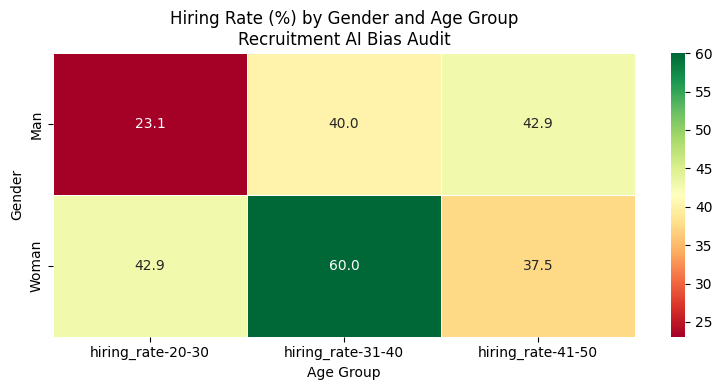

In [21]:
# Seaborn heatmap: hiring rates by gender and age group
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_table_display, 
            annot=True, 
            fmt='.1f', 
            cmap='RdYlGn',
            linewidths=0.5)
plt.title('Hiring Rate (%) by Gender and Age Group\nRecruitment AI Bias Audit')
plt.ylabel('Gender')
plt.xlabel('Age Group')
plt.tight_layout()
plt.show()